# S&P 500 - Workforce Analysis Report (Weights considered)
## Comprehensive Statistical Analysis
---

In [37]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings('ignore')

# Create output directory for plots
output_dir = 'output/company_overview'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory created: {output_dir}")

# Set McKinsey-style plotting parameters
plt.style.use('seaborn-v0_8-whitegrid')
MCKINSEY_BLUE = '#0077B6'
MCKINSEY_GRAY = '#4A4A4A'
MCKINSEY_LIGHT_BLUE = '#00B4D8'
MCKINSEY_PALETTE = ['#0077B6', '#00B4D8', '#90E0EF', '#CAF0F8', '#4A4A4A']

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

# Helper functions for weighted calculations
def weighted_value_counts(df, col, weight_col='weight'):
    """Calculate weighted counts for a categorical column"""
    valid = df[[col, weight_col]].dropna()
    return valid.groupby(col)[weight_col].sum().sort_values(ascending=False)

def weighted_mean(df, col, weight_col='weight'):
    """Calculate weighted mean"""
    valid = df[[col, weight_col]].dropna()
    return np.average(valid[col], weights=valid[weight_col])

def weighted_percentile(df, col, percentile, weight_col='weight'):
    """Weighted percentile using cumulative weight interpolation.

    Handles edge cases: empty input → NaN, percentile ≥ 1.0 → max value.
    """
    valid = df[[col, weight_col]].dropna()
    if len(valid) == 0:
        return np.nan
    valid = valid.sort_values(col)
    w = valid[weight_col].values
    v = valid[col].values
    cumw = np.cumsum(w)
    total = cumw[-1]
    if total == 0:
        return np.nan
    cutoff = total * percentile
    idx = np.searchsorted(cumw, cutoff, side='right')
    return v[min(idx, len(v) - 1)]

def weighted_std(df, col, weight_col='weight'):
    """Calculate weighted standard deviation"""
    valid = df[[col, weight_col]].dropna()
    avg = np.average(valid[col], weights=valid[weight_col])
    variance = np.average((valid[col] - avg)**2, weights=valid[weight_col])
    return np.sqrt(variance)

def valid_sex_mask(df, sex_col='sex_predicted'):
    """Consistent gender mask: non-null AND not '.' (placeholder)."""
    return df[sex_col].notna() & (df[sex_col] != ".")

print("Libraries loaded successfully")
print("✓ Weighted calculation helpers defined")

Output directory created: output/company_overview
Libraries loaded successfully
✓ Weighted calculation helpers defined


In [38]:
# Load the company data
df = pd.read_parquet('data/sp500_company_data.parquet')
df["weight"] = df["weight"].fillna(1.0)
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Column names: {df.columns.tolist()}")

n_rows = len(df)
n_users = df["user_id"].nunique() if "user_id" in df.columns else None
w_total = df["weight"].sum()
print(f"\nRows (employee-position records): {n_rows:,}")
if n_users is not None:
    print(f"Unique users (user_id):           {n_users:,}")
    print(f"Avg positions per user:           {n_rows / n_users:.2f}")
print(f"Weighted total:                   {w_total:,.0f}")
print(
    "\nNOTE: Each row is one employee-position record. A single user_id"
    "\ncan appear in multiple rows (e.g. job changes or multiple roles)."
    "\nAll statistics in this notebook use the 'weight' column, so"
    "\n'n_employees' throughout refers to weighted position-records,"
    "\nnot unique individuals."
)

Dataset loaded: 23,244,615 employees, 16 columns

Column names:
['user_id', 'position_id', 'rcid', 'seniority', 'country', 'salary', 'onet_code', 'startdate', 'enddate', 'weight', 'highest_degree', 'sex_predicted', 'ethnicity_predicted', 'ticker', 'naics_code', 'company']


In [39]:
# Add onet_title column by mapping from dwa_times_normalized
dwa_df = pd.read_parquet('data/dwa_times_normalized.parquet')

# Create mapping from O*NET-SOC Code to Title (get unique pairs)
onet_mapping = dwa_df[['O*NET-SOC Code', 'Title']].drop_duplicates().set_index('O*NET-SOC Code')['Title']

# Map to add onets_title column
df['onets_title'] = df['onet_code'].map(onet_mapping)

# Statistics on mapping
mapped_count = df['onets_title'].notna().sum()
total_count = len(df)
unmapped_count = df['onet_code'].notna().sum() - mapped_count

print(f"✓ Added 'onets_title' column")
print(f"  Mapped: {mapped_count:,} / {total_count:,} rows ({mapped_count/total_count*100:.1f}%)")
print(f"  Unique O*NET titles (in reference data): {dwa_df['O*NET-SOC Code'].nunique():,}")
print(f"  Unique O*NET codes in employee data: {df['onet_code'].nunique():,}, Currently in ONETS database 1016.")
if unmapped_count > 0:
    unmapped_codes_list = sorted(df[df['onet_code'].notna() & df['onets_title'].isna()]['onet_code'].unique())
    print(f"  ⚠️ {len(unmapped_codes_list)} O*NET codes not in reference data (will be excluded from position analysis, these do not have task ratings data available.")
    print(f"\n  Unmapped codes:")
    for code in unmapped_codes_list:
        print(f"    {code}")

✓ Added 'onets_title' column
  Mapped: 21,093,080 / 23,244,615 rows (90.7%)
  Unique O*NET titles (in reference data): 923
  Unique O*NET codes in employee data: 1,010, Currently in ONETS database 1016.
  ⚠️ 93 O*NET codes not in reference data (will be excluded from position analysis, these do not have task ratings data available.

  Unmapped codes:
    11-9039.00
    11-9179.00
    11-9199.00
    13-1199.00
    13-2099.00
    15-1299.00
    15-2099.00
    17-2199.00
    17-3019.00
    17-3029.00
    19-1029.00
    19-1099.00
    19-2099.00
    19-3039.00
    19-3099.00
    19-4099.00
    21-1019.00
    21-1029.00
    21-1099.00
    21-2099.00
    23-2099.00
    25-1069.00
    25-1199.00
    25-2059.00
    25-3099.00
    25-9049.00
    25-9099.00
    27-1019.00
    27-1029.00
    27-2099.00
    27-3099.00
    27-4099.00
    29-1029.00
    29-1129.00
    29-1229.00
    29-1249.00
    29-1299.00
    29-2099.00
    29-9099.00
    31-9099.00
    33-1099.00
    33-9099.00
    35-2019.00
  

It appears that all the "All other" ONETs job categiries are not present in my pi, ARS file. Thats probs bc we are missing some occs that did not have a task time value.

In [40]:
# Display first few rows and data types
print("\n=== Data Preview ===")
display(df.head())
print("\n=== Data Types ===")
display(df.dtypes)
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))


=== Data Preview ===


,user_id,position_id,rcid,seniority,country,salary,onet_code,startdate,enddate,weight,highest_degree,sex_predicted,ethnicity_predicted,ticker,naics_code,company,onets_title
0,655444319.0,-7785932349259996160.0,68.0,2,United States,83775.55,17-2112.03,2012-05-01,<NA>,1.249402,<NA>,M,Black,WAB,336510,Westinghouse Air Brake Technologies Corp.,Manufacturing Engineers
1,1691194.0,-4185719328929451008.0,68.0,3,United States,131183.48,17-2199.06,1992-08-01,<NA>,1.015331,Bachelor,M,White,WAB,336510,Westinghouse Air Brake Technologies Corp.,Microsystems Engineers
2,1691194.0,-861084181087021824.0,68.0,4,United States,133435.49,17-2199.00,2017-05-01,<NA>,1.015331,Bachelor,M,White,WAB,336510,Westinghouse Air Brake Technologies Corp.,NaN
3,2763094.0,-8711480916433658880.0,68.0,2,United States,73069.44,11-3061.00,<NA>,<NA>,1.094262,<NA>,M,White,WAB,336510,Westinghouse Air Brake Technologies Corp.,Purchasing Managers
4,3042300.0,5710354076206946304.0,68.0,2,United Kingdom,46880.36,49-3021.00,2006-02-01,<NA>,1.187465,<NA>,M,White,WAB,336510,Westinghouse Air Brake Technologies Corp.,Automotive Body and Related Repairers



=== Data Types ===


user_id                       Float64
position_id                   Float64
rcid                          float64
seniority                       Int64
country                string[python]
salary                        Float64
onet_code              string[python]
startdate              string[python]
enddate                string[python]
weight                        Float64
highest_degree         string[python]
sex_predicted          string[python]
ethnicity_predicted    string[python]
ticker                 string[python]
naics_code             string[python]
company                string[python]
onets_title                    object
dtype: object


=== Missing Values ===


,Missing Count,Percentage
enddate,23244615,100.00
highest_degree,10852691,46.69
startdate,4541995,19.54
onets_title,2151535,9.26
country,330136,1.42
onet_code,10767,0.05
ethnicity_predicted,4853,0.02
salary,3624,0.02
weight,18,0.00


In [41]:
# ══════════════════════════════════════════════════════════════════════
# SP500 DATASET — HIGH-LEVEL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════

w = df["weight"].fillna(1.0)

total_rows      = len(df)
weighted_total  = w.sum()
n_companies     = df["company"].nunique()  if "company"  in df.columns else df["ticker"].nunique()
n_tickers       = df["ticker"].nunique()   if "ticker"   in df.columns else np.nan
n_unique_users  = df["user_id"].nunique()  if "user_id"  in df.columns else np.nan
n_occupations   = df["onet_code"].nunique() if "onet_code" in df.columns else np.nan

sex_mask  = df["sex_predicted"].notna() & (df["sex_predicted"] != ".")
w_sex     = w[sex_mask]
pct_female = 100 * w_sex[df.loc[sex_mask, "sex_predicted"] == "F"].sum() / w_sex.sum() if w_sex.sum() > 0 else np.nan

sal_mask      = df["salary"].notna() if "salary" in df.columns else pd.Series(False, index=df.index)
avg_salary    = np.average(df.loc[sal_mask, "salary"], weights=w[sal_mask]) if w[sal_mask].sum() > 0 else np.nan
median_salary = weighted_percentile(df, "salary", 0.5) if "salary" in df.columns else np.nan

sen_mask      = df["seniority"].notna() if "seniority" in df.columns else pd.Series(False, index=df.index)
avg_seniority = np.average(df.loc[sen_mask, "seniority"], weights=w[sen_mask]) if w[sen_mask].sum() > 0 else np.nan

edu_mask = df["highest_degree"].notna() if "highest_degree" in df.columns else pd.Series(False, index=df.index)
w_edu = w[edu_mask]
edu = df.loc[edu_mask, "highest_degree"]
pct_bach_plus = 100 * w_edu[edu.isin(["Bachelor","Master","MBA","Doctor"])].sum() / w_edu.sum() if w_edu.sum() > 0 else np.nan

eth_mask = df["ethnicity_predicted"].notna() if "ethnicity_predicted" in df.columns else pd.Series(False, index=df.index)
w_eth = w[eth_mask]
eth = df.loc[eth_mask, "ethnicity_predicted"]
w_eth_total = w_eth.sum()
eth_shares = {}
for e in ["White", "Black", "Hispanic", "API"]:
    eth_shares[e] = f"{100*w_eth[eth==e].sum()/w_eth_total:.1f}%" if w_eth_total > 0 else "N/A"

summary = pd.DataFrame([
    ("Companies (unique tickers)",  f"{n_tickers:,.0f}"),
    ("Total employee-position rows", f"{total_rows:,}"),
    ("Weighted employee total",     f"{weighted_total:,.0f}"),
    ("Unique employees (user_id)",  f"{n_unique_users:,}"),
    ("Unique occupations (O*NET)",  f"{n_occupations:,.0f}"),
    ("Average salary (weighted)",   f"${avg_salary:,.0f}"),
    ("Median salary (weighted)",    f"${median_salary:,.0f}"),
    ("Average seniority (weighted)",f"{avg_seniority:.2f}"),
    ("% Female (weighted)",         f"{pct_female:.1f}%"),
    ("% Bachelor's+ (weighted)",    f"{pct_bach_plus:.1f}%"),
    ("% White (weighted)",          eth_shares.get("White", "N/A")),
    ("% Black (weighted)",          eth_shares.get("Black", "N/A")),
    ("% Hispanic (weighted)",       eth_shares.get("Hispanic", "N/A")),
    ("% Asian / Pacific Isl. (weighted)", eth_shares.get("API", "N/A")),
], columns=["Metric", "Value"])

print("=" * 56)
print("  S&P 500 WORKFORCE — DATASET OVERVIEW")
print("=" * 56)
display(summary.style.hide(axis="index").set_properties(**{
    "text-align": "left", "font-size": "12px"
}).set_table_styles([
    {"selector": "th", "props": [("text-align", "left"), ("font-weight", "bold")]},
]))

  S&P 500 WORKFORCE — DATASET OVERVIEW


Metric,Value
Companies (unique tickers),473
Total employee-position rows,"23,244,615"
Weighted employee total,"26,866,152"
Unique employees (user_id),"21,626,407"
Unique occupations (O*NET),"1,010"
Average salary (weighted),"$70,882"
Median salary (weighted),"$51,583"
Average seniority (weighted),2.59
% Female (weighted),38.9%
% Bachelor's+ (weighted),91.0%


---
## Section 0: Descriptive Statistics
### Key Workforce Demographics

In [42]:
# Gender Distribution (Weighted)
print("=" * 60)
print("GENDER DISTRIBUTION (WEIGHTED)")
print("=" * 60)

gender_col = 'sex_predicted'

if gender_col in df.columns:
    # Exclude rows where sex_predicted is null OR "." (placeholder)
    sex_mask = valid_sex_mask(df, gender_col)
    df_sex = df.loc[sex_mask]
    w_sex = df_sex["weight"]

    gender_counts = df_sex.groupby(gender_col)["weight"].sum().sort_values(ascending=False)
    total_weight = gender_counts.sum()
    gender_pct = (gender_counts / total_weight * 100).round(2)

    gender_summary = pd.DataFrame({
        'Weighted Count': gender_counts.round(0).astype(int),
        'Percentage': gender_pct
    })
    display(gender_summary)

    female_w = w_sex[df_sex[gender_col] == "F"].sum()
    female_pct = 100 * female_w / total_weight if total_weight > 0 else np.nan
    print(f"\n📊 Female representation (weighted, excl. '.'): {female_pct:.1f}%")
else:
    print("⚠️ Gender column not found in dataset")

GENDER DISTRIBUTION (WEIGHTED)


,Weighted Count,Percentage
sex_predicted,,
M,16292116,60.64
F,10352539,38.53
.,221479,0.82



📊 Female representation (weighted): 38.5%


In [43]:
# Ethnicity Distribution (Weighted)
print("\n" + "=" * 60)
print("ETHNICITY DISTRIBUTION (WEIGHTED)")
print("=" * 60)

# Use the correct ethnicity column name
ethnicity_col = 'ethnicity_predicted'

if ethnicity_col in df.columns:
    # Weighted counts
    ethnicity_counts = weighted_value_counts(df, ethnicity_col, 'weight')
    total_weight = ethnicity_counts.sum()
    ethnicity_pct = (ethnicity_counts / total_weight * 100).round(2)
    
    ethnicity_summary = pd.DataFrame({
        'Weighted Count': ethnicity_counts.round(0).astype(int),
        'Percentage': ethnicity_pct
    })
    
    display(ethnicity_summary)
    print(f"\n📊 Diversity index: {len(ethnicity_counts)} ethnic groups represented")
else:
    print("⚠️ Ethnicity column not found in dataset")


ETHNICITY DISTRIBUTION (WEIGHTED)


,Weighted Count,Percentage
ethnicity_predicted,,
White,14748706,54.91
API,6809620,25.35
Hispanic,3031345,11.29
Black,2097666,7.81
Multiple,153002,0.57
Native,20399,0.08



📊 Diversity index: 6 ethnic groups represented


In [44]:
# Education/Schooling Distribution (Weighted)
print("\n" + "=" * 60)
print("EDUCATION DISTRIBUTION (WEIGHTED)")
print("=" * 60)

# Use the correct education column name
education_col = 'highest_degree'

if education_col in df.columns:
    # Weighted counts
    education_counts = weighted_value_counts(df, education_col, 'weight').head(10)
    total_weight = weighted_value_counts(df, education_col, 'weight').sum()
    education_pct = (education_counts / total_weight * 100).round(2)
    
    education_summary = pd.DataFrame({
        'Weighted Count': education_counts.round(0).astype(int),
        'Percentage': education_pct
    })
    
    display(education_summary)
else:
    print("⚠️ Education column not found in dataset")


EDUCATION DISTRIBUTION (WEIGHTED)


,Weighted Count,Percentage
highest_degree,,
Bachelor,7658310,54.0
Master,3175244,22.39
MBA,1539461,10.85
Associate,731033,5.15
High School,541931,3.82
Doctor,536872,3.79


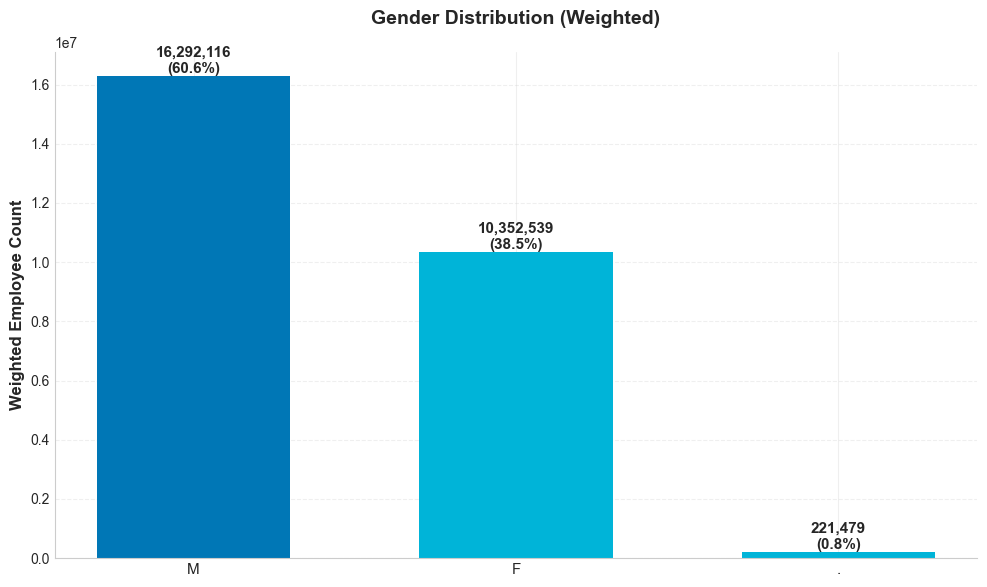

✓ Saved: output/company_overview/01_gender_distribution.png


In [45]:
# Visualize Gender Distribution (Weighted, excl. "." rows)
if gender_col in df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))

    df_sex_viz = df.loc[valid_sex_mask(df, gender_col)]
    gender_data = df_sex_viz.groupby(gender_col)["weight"].sum().sort_values(ascending=False)
    colors = [MCKINSEY_BLUE if i == 0 else MCKINSEY_LIGHT_BLUE for i in range(len(gender_data))]

    bars = ax.bar(range(len(gender_data)), gender_data.values, color=colors, width=0.6)

    for i, (bar, val) in enumerate(zip(bars, gender_data.values)):
        height = bar.get_height()
        pct = (val / gender_data.sum() * 100)
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:,.0f}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(range(len(gender_data)))
    ax.set_xticklabels(gender_data.index, fontsize=11)
    ax.set_ylabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Gender Distribution (Weighted, excl. "." rows)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/01_gender_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/01_gender_distribution.png")

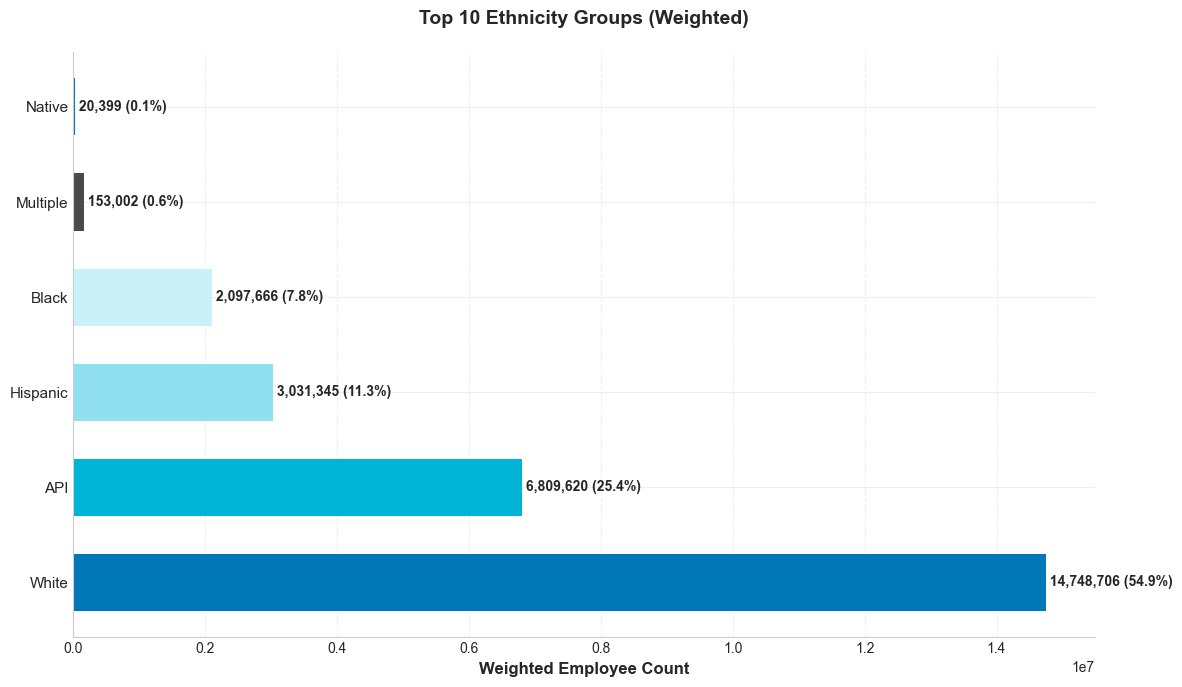

✓ Saved: output/company_overview/02_ethnicity_distribution.png


In [46]:
# Visualize Ethnicity Distribution - McKinsey Style (Weighted)
if ethnicity_col in df.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    ethnicity_data = weighted_value_counts(df, ethnicity_col, 'weight').head(10)
    total_weight = weighted_value_counts(df, ethnicity_col, 'weight').sum()
    colors = [MCKINSEY_PALETTE[i % len(MCKINSEY_PALETTE)] for i in range(len(ethnicity_data))]
    
    bars = ax.barh(range(len(ethnicity_data)), ethnicity_data.values, color=colors, height=0.6)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, ethnicity_data.values)):
        width = bar.get_width()
        pct = (val / total_weight * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,.0f} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(ethnicity_data)))
    ax.set_yticklabels(ethnicity_data.index, fontsize=11)
    ax.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Ethnicity Groups (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/02_ethnicity_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/02_ethnicity_distribution.png")

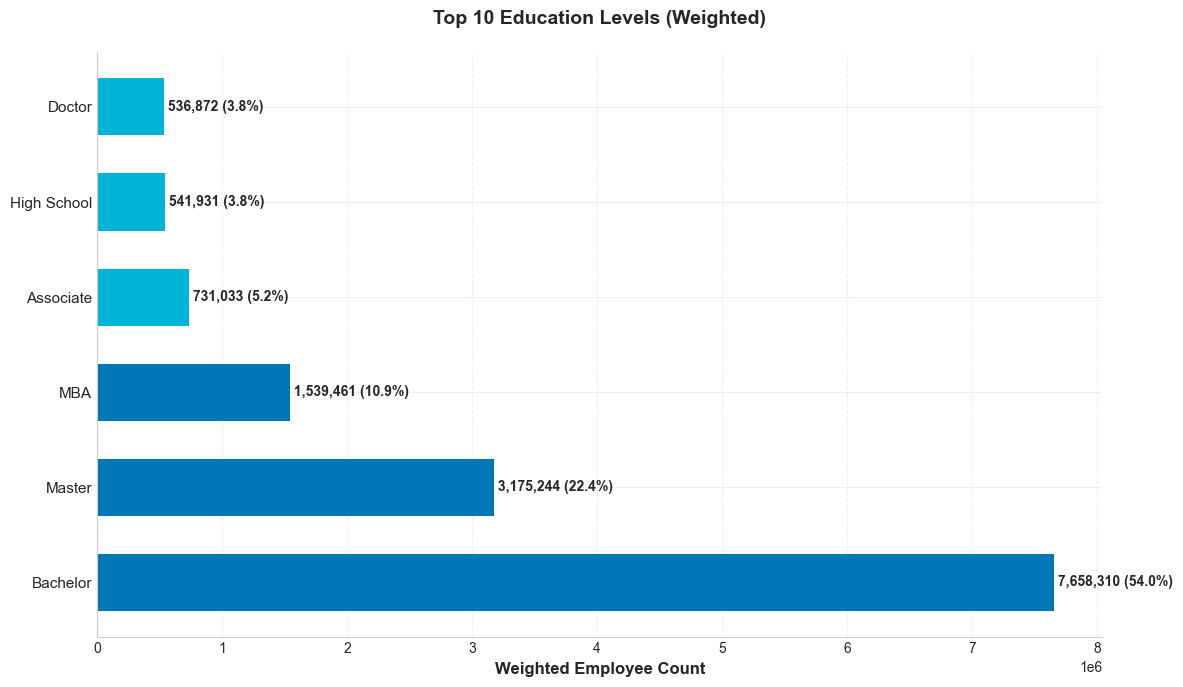

✓ Saved: output/company_overview/03_education_distribution.png


In [47]:
# Visualize Education Distribution - McKinsey Style (Weighted)
if education_col in df.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    education_data = weighted_value_counts(df, education_col, 'weight').head(10)
    total_weight = weighted_value_counts(df, education_col, 'weight').sum()
    colors = [MCKINSEY_BLUE if i < 3 else MCKINSEY_LIGHT_BLUE for i in range(len(education_data))]
    
    bars = ax.barh(range(len(education_data)), education_data.values, color=colors, height=0.6)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, education_data.values)):
        width = bar.get_width()
        pct = (val / total_weight * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,.0f} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(education_data)))
    ax.set_yticklabels(education_data.index, fontsize=11)
    ax.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Education Levels (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/03_education_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/03_education_distribution.png")

---
## Section 1: Position Analysis
### Most Common Job Titles

In [48]:
# Use O*NET codes for position analysis (Weighted)
position_code_col = 'onet_code'
position_title_col = 'onets_title'

if position_code_col in df.columns and position_title_col in df.columns:
    print("=" * 60)
    print("TOP 20 MOST COMMON POSITIONS (WEIGHTED)")
    print("=" * 60)
    
    # Filter to only rows with valid O*NET titles (exclude unmapped codes)
    df_valid_positions = df[df[position_title_col].notna()].copy()
    
    # Group by onet_code and get the first onet_title for each code
    position_mapping = df_valid_positions.groupby(position_code_col)[position_title_col].first()
    
    # Weighted position counts (only for mapped positions)
    all_positions_wt = weighted_value_counts(df_valid_positions, position_code_col, 'weight')
    mapped_total_weight = all_positions_wt.sum()
    full_total_weight = df['weight'].sum()
    position_counts = all_positions_wt.head(20)
    position_pct = (position_counts / mapped_total_weight * 100).round(2)

    position_summary = pd.DataFrame({
        'Position': [position_mapping[code] for code in position_counts.index],
        'Weighted Count': position_counts.values.round(0).astype(int),
        '% of Mapped Subset': position_pct.values
    })

    display(position_summary)

    valid_unique = df_valid_positions[position_code_col].nunique()
    total_unique = df[position_code_col].nunique()
    unmapped_codes = total_unique - valid_unique
    mapped_share = 100 * mapped_total_weight / full_total_weight

    print(f"\n📊 Total unique positions (O*NET codes with titles): {valid_unique:,}")
    print(f"   Mapped subset covers {mapped_total_weight:,.0f} / {full_total_weight:,.0f} weighted employees ({mapped_share:.1f}%)")
    if unmapped_codes > 0:
        print(f"⚠️ {unmapped_codes} O*NET codes excluded (not in reference data)")
    print("   Percentages above are shares within the mapped subset only.")
else:
    print("⚠️ Position columns (onet_code, onets_title) not found in dataset")

TOP 20 MOST COMMON POSITIONS (WEIGHTED)


,Position,Weighted Count,Percentage
0,Software Developers,1480407,6.09
1,Information Technology Project Managers,717750,2.95
2,"Sales Representatives, Wholesale and Manufactu...",659935,2.71
3,Computer Systems Engineers/Architects,584220,2.4
4,Sales Managers,559778,2.3
5,Business Intelligence Analysts,539746,2.22
6,Marketing Managers,532220,2.19
7,Customer Service Representatives,524255,2.16
8,Treasurers and Controllers,427307,1.76
9,Retail Salespersons,381232,1.57



📊 Total unique positions (O*NET codes with titles): 917
⚠️ 93 O*NET codes excluded (not in reference data)


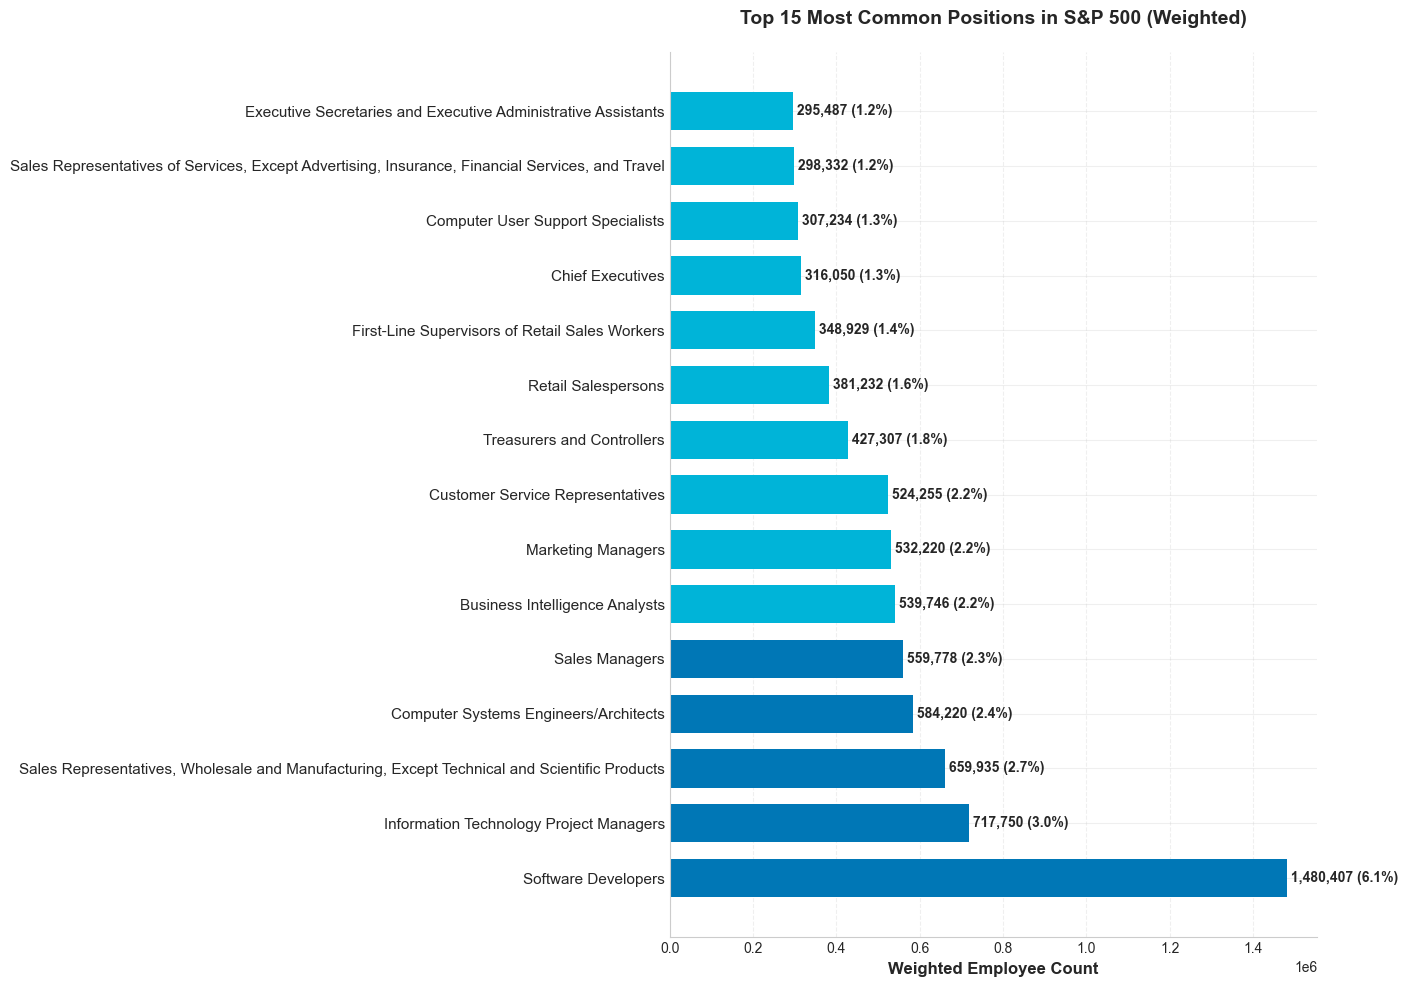

✓ Saved: output/company_overview/04_top_positions.png


In [49]:
# Visualize Top Positions - McKinsey Style (Weighted)
if position_code_col in df.columns and position_title_col in df.columns:
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Use only rows with valid O*NET titles
    df_valid_positions = df[df[position_title_col].notna()].copy()
    
    # Get top 15 positions by weighted count
    top_codes = weighted_value_counts(df_valid_positions, position_code_col, 'weight').head(15)
    total_weight = df_valid_positions['weight'].sum()
    position_mapping = df_valid_positions.groupby(position_code_col)[position_title_col].first()
    position_titles = [position_mapping[code] for code in top_codes.index]
    
    colors = [MCKINSEY_BLUE if i < 5 else MCKINSEY_LIGHT_BLUE for i in range(len(top_codes))]
    
    bars = ax.barh(range(len(top_codes)), top_codes.values, color=colors, height=0.7)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, top_codes.values)):
        width = bar.get_width()
        pct = (val / total_weight * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,.0f} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(top_codes)))
    ax.set_yticklabels(position_titles, fontsize=11)
    ax.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Top 15 Most Common Positions in S&P 500 (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/04_top_positions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/04_top_positions.png")

---
## Section 2: Geographic Analysis
### Employee Location Mapping

In [50]:
# Load world cities data for coordinates
import zipfile

print("Loading world cities database...")
with zipfile.ZipFile('data/simplemaps_worldcities_basicv1.901.zip', 'r') as zip_ref:
    # Find the CSV file in the zip
    csv_files = [f for f in zip_ref.namelist() if f.endswith('.csv')]
    if csv_files:
        with zip_ref.open(csv_files[0]) as csv_file:
            cities_df = pd.read_csv(csv_file)
            print(f"✓ Loaded {len(cities_df):,} cities")
            print(f"\nCities columns: {cities_df.columns.tolist()}")
            display(cities_df.head())

Loading world cities database...


✓ Loaded 48,059 cities

Cities columns: ['city', 'city_ascii', 'lat', 'lng', 'country', 'iso2', 'iso3', 'admin_name', 'capital', 'population', 'id']


,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
0,Tokyo,Tokyo,35.6870,139.7495,Japan,JP,JPN,Tōkyō,primary,37785000.0,1392685764
1,Jakarta,Jakarta,-6.1750,106.8275,Indonesia,ID,IDN,Jakarta,primary,33756000.0,1360771077
2,Delhi,Delhi,28.6100,77.2300,India,IN,IND,Delhi,admin,32226000.0,1356872604
3,Guangzhou,Guangzhou,23.1300,113.2600,China,CN,CHN,Guangdong,admin,26940000.0,1156237133
4,Mumbai,Mumbai,19.0761,72.8775,India,IN,IND,Mahārāshtra,admin,24973000.0,1356226629


In [51]:
# Find city column in employee data
city_col = None
for col in df.columns:
    if 'city' in col.lower() or 'location' in col.lower():
        city_col = col
        break

if city_col:
    print(f"Found city column: {city_col}")
    print(f"\nTop 10 cities in employee data (weighted):")
    display(weighted_value_counts(df, city_col, 'weight').head(10).round(0).astype(int))
else:
    print("⚠️ City column not found. Will check for other location columns...")
    location_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['city', 'location', 'place', 'region'])]
    print(f"Potential location columns: {location_cols}")

Found city column: ethnicity_predicted

Top 10 cities in employee data:


ethnicity_predicted
White       13235514
API          5419235
Hispanic     2598905
Black        1840057
Multiple      128171
Native         17880
Name: count, dtype: Int64

In [52]:
# Merge employee data with city coordinates (US-only, many-to-one)
if city_col:
    df['city_clean'] = df[city_col].astype(str).str.strip().str.lower()

    # Restrict to US cities and deduplicate: keep the largest city per name
    us_cities = cities_df[cities_df['country'] == 'United States'].copy()
    us_cities['city_clean'] = us_cities['city'].astype(str).str.strip().str.lower()
    us_cities['population'] = pd.to_numeric(us_cities['population'], errors='coerce').fillna(0)
    city_lookup = (
        us_cities.sort_values('population', ascending=False)
        .drop_duplicates(subset='city_clean', keep='first')
        [['city_clean', 'lat', 'lng']]
    )
    n_us_before = len(us_cities)
    n_us_after  = len(city_lookup)
    print(f"US cities: {n_us_before:,} → {n_us_after:,} after dedup (largest pop kept)")

    # Validated many-to-one merge: city_lookup has unique city_clean
    assert city_lookup['city_clean'].is_unique, "city_lookup should be unique"
    df_geo = df.merge(city_lookup, on='city_clean', how='left', validate='many_to_one')

    # Stats from the merged frame (no row duplication since lookup is unique)
    matched_weight = df_geo.loc[df_geo['lat'].notna(), 'weight'].sum()
    total_weight = df_geo['weight'].sum()
    assert abs(total_weight - df['weight'].sum()) < 1, "Merge should not change total weight"
    match_rate = (matched_weight / total_weight * 100)

    print(f"\n📍 Matched {matched_weight:,.0f} / {total_weight:,.0f} weighted employees ({match_rate:.1f}%)")
    print("   (US cities only; ambiguous names resolved to largest city by population)")
    print(f"\nTop 10 employee locations (weighted):")
    location_counts = df_geo[df_geo['lat'].notna()].groupby(city_col)['weight'].sum().sort_values(ascending=False).head(10)
    display(location_counts.round(0).astype(int))
else:
    print("⚠️ Cannot proceed with geographic analysis without city data")


📍 Successfully matched 14,748,706 / 26,866,134 weighted employees (54.9%)

Top 10 employee locations (weighted):


ethnicity_predicted
White    14748706
Name: weight, dtype: int64

In [53]:
# Create interactive map with employee locations - McKinsey Style (USA only, Weighted)
if city_col and 'lat' in df_geo.columns:
    # Aggregate by location (weighted)
    map_data = df_geo[df_geo['lat'].notna()].groupby(
        [city_col, 'lat', 'lng']
    )['weight'].sum().reset_index(name='employee_count')
    
    # Create map using scatter_mapbox for actual map visualization
    fig = px.scatter_mapbox(
        map_data,
        lat='lat',
        lon='lng',
        size='employee_count',
        hover_name=city_col,
        hover_data={
            'employee_count': ':,',
            'lat': ':.4f',
            'lng': ':.4f'
        },
        color='employee_count',
        color_continuous_scale=[
            [0, '#FFE5E5'],
            [0.5, '#FF6B6B'],
            [1, '#CC0000']
        ],
        size_max=50,
        zoom=3,
        center={'lat': 37.0902, 'lon': -95.7129},  # Center of USA
        title='<b>S&P 500 Employee Geographic Distribution (USA)</b>',
        mapbox_style='open-street-map'  # Use OpenStreetMap for free map tiles
    )
    
    fig.update_layout(
        font=dict(family="Arial, sans-serif", size=12),
        title_font=dict(size=16, color='#4A4A4A'),
        coloraxis_colorbar=dict(
            title="Employees",
            tickformat=','
        ),
        height=700,
        margin={"r":0,"t":50,"l":0,"b":0}
    )
    
    # fig.write_html(f'{output_dir}/05_employee_geographic_map.html')
    # fig.show()
    # print(f"✓ Saved: {output_dir}/05_employee_geographic_map.html")

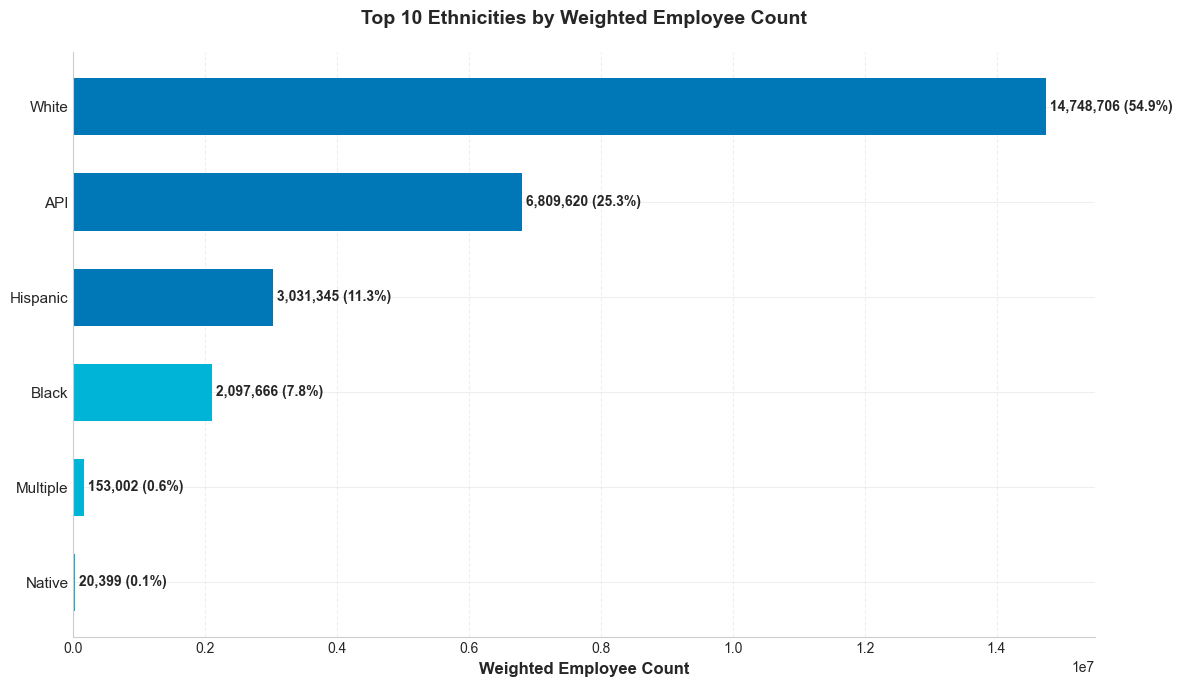

✓ Saved: output/company_overview/06_top_cities.png


In [54]:
# Top 10 cities visualization - McKinsey Style (Weighted)
if city_col:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    city_data = weighted_value_counts(df, city_col, 'weight').head(10)
    total_weight = df['weight'].sum()
    colors = [MCKINSEY_BLUE if i < 3 else MCKINSEY_LIGHT_BLUE for i in range(len(city_data))]
    
    bars = ax.barh(range(len(city_data)), city_data.values, color=colors, height=0.6)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, city_data.values)):
        width = bar.get_width()
        pct = (val / total_weight * 100)
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {val:,.0f} ({pct:.1f}%)',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(city_data)))
    ax.set_yticklabels(city_data.index, fontsize=11)
    ax.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Cities by Weighted Employee Count', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/06_top_cities.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/06_top_cities.png")

---
## Section 3: Remote Work Analysis
### Remote Suitability Distribution

In [55]:
# Find remote work column
remote_col = None
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['remote', 'wfh', 'work_from_home', 'telework']):
        remote_col = col
        break

if remote_col:
    print("=" * 60)
    print("REMOTE WORK SUITABILITY ANALYSIS (WEIGHTED)")
    print("=" * 60)
    
    # Weighted remote counts
    remote_counts = weighted_value_counts(df, remote_col, 'weight')
    total_weight = remote_counts.sum()
    remote_pct = (remote_counts / total_weight * 100).round(2)
    
    remote_summary = pd.DataFrame({
        'Weighted Count': remote_counts.round(0).astype(int),
        'Percentage': remote_pct
    })
    
    display(remote_summary)
    
    print(f"\n📊 Remote work data available for: {df.loc[df[remote_col].notna(), 'weight'].sum():,.0f} weighted employees")
else:
    print("⚠️ Remote work column not found in dataset")
    print("Searching for related columns...")
    work_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['work', 'office', 'location'])]
    print(f"Potential work-related columns: {work_cols}")

⚠️ Remote work column not found in dataset
Searching for related columns...
Potential work-related columns: []


In [56]:
if remote_col:
    if df[remote_col].dtype in ['int64', 'float64']:
        # ── Numeric remote suitability score ───────────────────────────
        _rm_valid = df[[remote_col, 'weight']].dropna()
        _rm_vals = _rm_valid[remote_col].values
        _rm_w    = _rm_valid['weight'].values
        _rm_wmean = np.average(_rm_vals, weights=_rm_w)
        _rm_wmed  = weighted_percentile(df, remote_col, 0.5)
        _rm_wstd  = weighted_std(df, remote_col, 'weight')

        fig, ax1 = plt.subplots(figsize=(10, 6))

        ax1.hist(_rm_vals, bins=30, weights=_rm_w,
                 color=MCKINSEY_BLUE, edgecolor='white', alpha=0.8)
        ax1.axvline(_rm_wmean, color=MCKINSEY_GRAY, linestyle='--', lw=2,
                    label=f'Wt. Mean: {_rm_wmean:.2f}')
        ax1.axvline(_rm_wmed, color='#FF6B6B', linestyle='--', lw=2,
                    label=f'Wt. Median: {_rm_wmed:.2f}')
        ax1.set_xlabel('Remote Suitability Score', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Weighted Count', fontsize=12, fontweight='bold')
        ax1.set_title('Remote Work Suitability (Weighted Histogram)', fontsize=14, fontweight='bold', pad=20)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3, linestyle='--')

        plt.tight_layout()
        plt.savefig(f'{output_dir}/07_remote_work_numeric.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: {output_dir}/07_remote_work_numeric.png")

        print(f"\n📊 Remote Suitability Statistics (weighted):")
        print(f"   Mean:    {_rm_wmean:.2f}")
        print(f"   Median:  {_rm_wmed:.2f}")
        print(f"   Std Dev: {_rm_wstd:.2f}")
        print(f"   Min:     {df[remote_col].min():.2f}")
        print(f"   Max:     {df[remote_col].max():.2f}")

    else:
        # ── Categorical remote work data → weighted bar chart ──────────
        cat_counts = weighted_value_counts(df, remote_col, 'weight')
        cat_total  = cat_counts.sum()
        cat_pct    = (cat_counts / cat_total * 100).round(1)

        fig, ax = plt.subplots(figsize=(12, 7))
        colors = [MCKINSEY_BLUE if i < 3 else MCKINSEY_LIGHT_BLUE for i in range(len(cat_counts))]
        bars = ax.barh(range(len(cat_counts)), cat_counts.values, color=colors, height=0.6)

        for i, (bar, val) in enumerate(zip(bars, cat_counts.values)):
            w = bar.get_width()
            ax.text(w, bar.get_y() + bar.get_height()/2.,
                    f' {val:,.0f} ({cat_pct.iloc[i]:.1f}%)',
                    ha='left', va='center', fontsize=10, fontweight='bold')

        ax.set_yticks(range(len(cat_counts)))
        ax.set_yticklabels(cat_counts.index, fontsize=11)
        ax.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
        ax.set_title('Remote Work Status (Weighted Bar Chart)', fontsize=14, fontweight='bold', pad=20)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.invert_yaxis()

        plt.tight_layout()
        plt.savefig(f'{output_dir}/07_remote_work_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: {output_dir}/07_remote_work_distribution.png")

---
## Section 4: Compensation Analysis
### Salary Distribution and Insights

In [57]:
# Find salary column
salary_col = None
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['salary', 'compensation', 'pay', 'wage', 'income']):
        salary_col = col
        break

if salary_col:
    print("=" * 60)
    print("SALARY ANALYSIS (WEIGHTED)")
    print("=" * 60)
    
    # Weighted salary statistics
    salary_data = df[[salary_col, 'weight']].dropna()
    total_weight = salary_data['weight'].sum()
    
    w_mean = weighted_mean(df, salary_col, 'weight')
    w_median = weighted_percentile(df, salary_col, 0.5, 'weight')
    w_std = weighted_std(df, salary_col, 'weight')
    w_25 = weighted_percentile(df, salary_col, 0.25, 'weight')
    w_75 = weighted_percentile(df, salary_col, 0.75, 'weight')
    
    print(f"\n📊 Weighted Salary Statistics:")
    print(f"   Total weighted count: {total_weight:,.0f}")
    print(f"   Weighted Mean: ${w_mean:,.2f}")
    print(f"   Weighted Median: ${w_median:,.2f}")
    print(f"   Weighted Std Dev: ${w_std:,.2f}")
    print(f"   Min: ${salary_data[salary_col].min():,.2f}")
    print(f"   25th percentile (weighted): ${w_25:,.2f}")
    print(f"   75th percentile (weighted): ${w_75:,.2f}")
    print(f"   Max: ${salary_data[salary_col].max():,.2f}")
else:
    print("⚠️ Salary column not found in dataset")
    comp_cols = [col for col in df.columns if any(kw in col.lower() for kw in ['salary', 'pay', 'comp', 'wage', 'income'])]
    print(f"Potential compensation columns: {comp_cols}")

SALARY ANALYSIS (WEIGHTED)

📊 Weighted Salary Statistics:
   Total weighted count: 26,862,094
   Weighted Mean: $70,882.29
   Weighted Median: $51,583.14
   Weighted Std Dev: $61,398.53
   Min: $0.00
   25th percentile (weighted): $27,481.53
   75th percentile (weighted): $98,330.63
   Max: $2,327,948.35


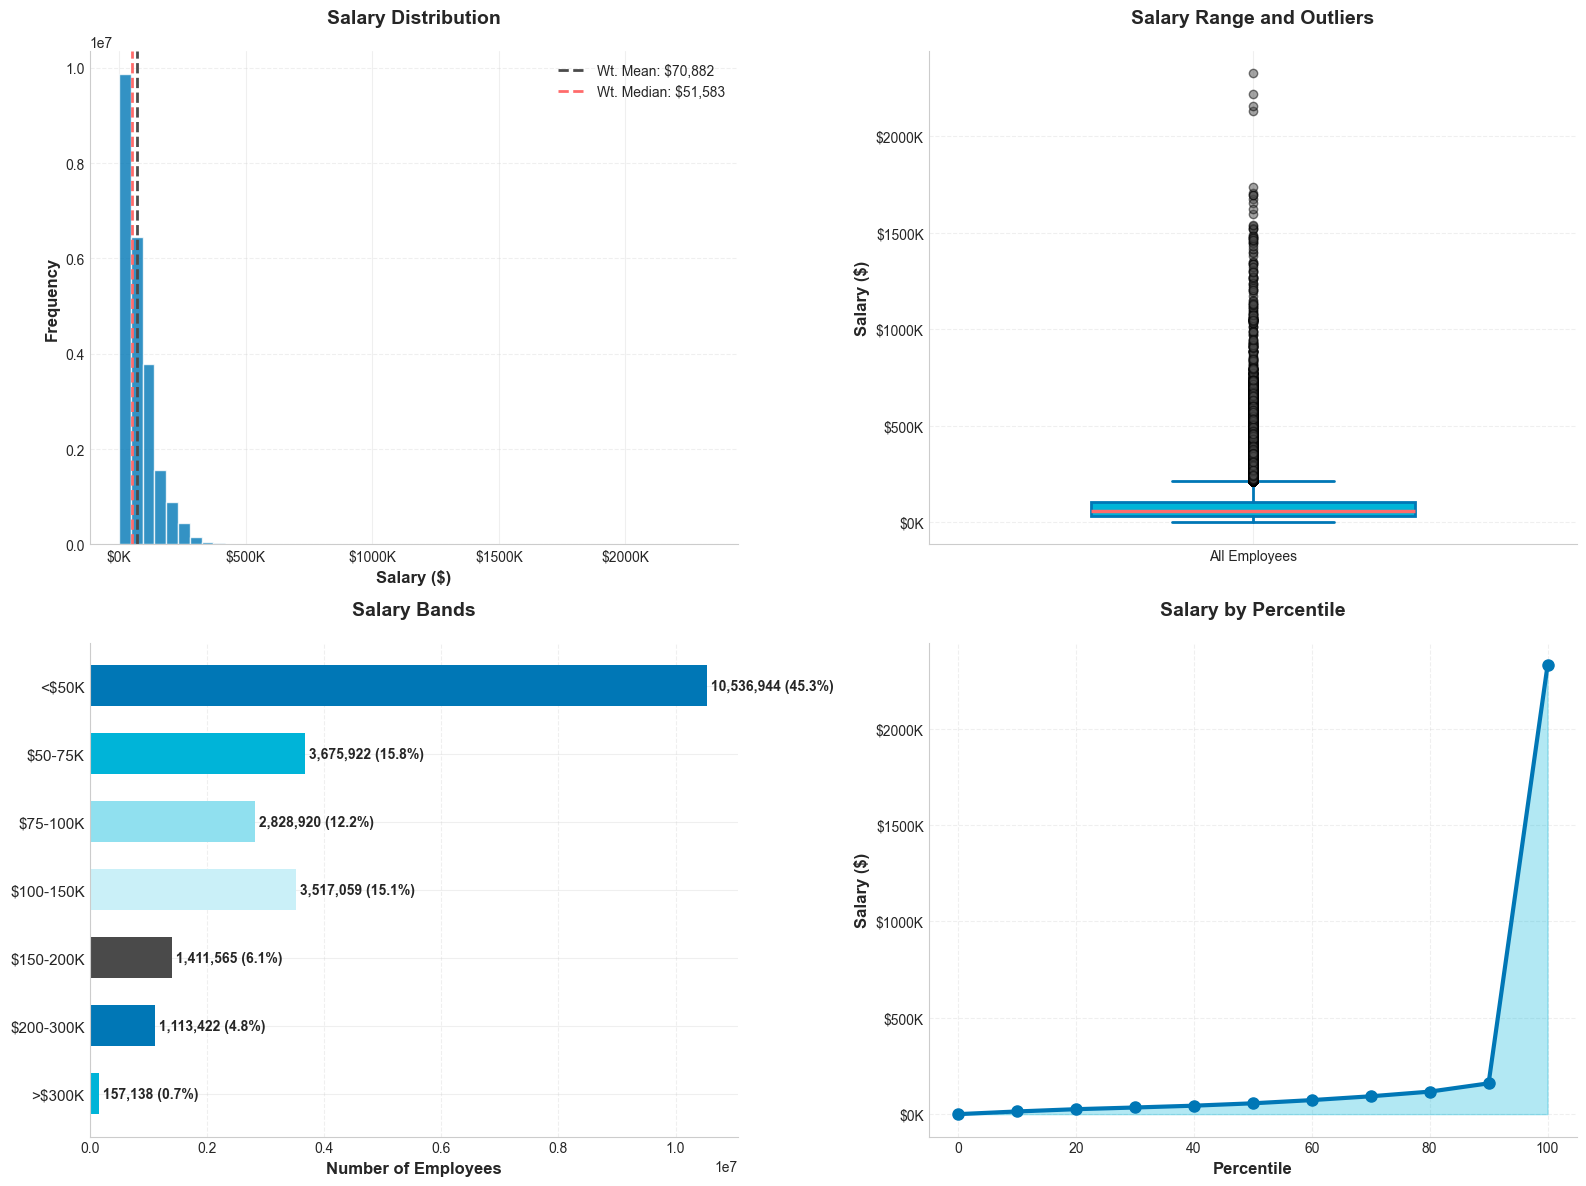

✓ Saved: output/company_overview/08_salary_distribution.png


In [58]:
# Visualize Salary Distribution (All panels weighted)
if salary_col:
    _sal_df = df[[salary_col, 'weight']].dropna()
    _sal_vals = _sal_df[salary_col].values
    _sal_w    = _sal_df['weight'].values
    _s_wmean  = np.average(_sal_vals, weights=_sal_w)
    _s_wmed   = weighted_percentile(df, salary_col, 0.5)

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # ── 1. Weighted histogram ──────────────────────────────────────────
    ax1.hist(_sal_vals, bins=50, weights=_sal_w,
             color=MCKINSEY_BLUE, edgecolor='white', alpha=0.8)
    ax1.axvline(_s_wmean, color=MCKINSEY_GRAY, ls='--', lw=2,
                label=f'Wt. Mean: ${_s_wmean:,.0f}')
    ax1.axvline(_s_wmed, color='#FF6B6B', ls='--', lw=2,
                label=f'Wt. Median: ${_s_wmed:,.0f}')
    ax1.set_xlabel('Salary ($)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Weighted Count', fontsize=12, fontweight='bold')
    ax1.set_title('Salary Distribution (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # ── 2. Box plot (unweighted — matplotlib boxplot has no weight param)
    bp = ax2.boxplot(_sal_vals, vert=True, patch_artist=True, widths=0.5,
                     boxprops=dict(facecolor=MCKINSEY_LIGHT_BLUE, edgecolor=MCKINSEY_BLUE, lw=2),
                     whiskerprops=dict(color=MCKINSEY_BLUE, lw=2),
                     capprops=dict(color=MCKINSEY_BLUE, lw=2),
                     medianprops=dict(color='#FF6B6B', lw=2.5),
                     flierprops=dict(marker='o', markerfacecolor=MCKINSEY_GRAY,
                                     markersize=4, alpha=0.3))
    ax2.set_ylabel('Salary ($)', fontsize=12, fontweight='bold')
    ax2.set_title('Salary Range (Unweighted Box Plot)', fontsize=14, fontweight='bold', pad=20)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_xticklabels(['All Employees'])
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    # ── 3. Salary bands (weighted sums) ────────────────────────────────
    bins_edges = [0, 50_000, 75_000, 100_000, 150_000, 200_000, 300_000, _sal_vals.max() + 1]
    band_labels = ['<$50K', '$50-75K', '$75-100K', '$100-150K', '$150-200K', '$200-300K', '>$300K']
    _sal_df_bands = _sal_df.copy()
    _sal_df_bands['band'] = pd.cut(_sal_df_bands[salary_col], bins=bins_edges, labels=band_labels)
    band_wt = _sal_df_bands.groupby('band', observed=False)['weight'].sum()
    band_wt_total = band_wt.sum()

    colors = [MCKINSEY_PALETTE[i % len(MCKINSEY_PALETTE)] for i in range(len(band_wt))]
    bars = ax3.barh(range(len(band_wt)), band_wt.values, color=colors, height=0.6)
    for i, (bar, val) in enumerate(zip(bars, band_wt.values)):
        w = bar.get_width()
        pct = 100 * val / band_wt_total
        ax3.text(w, bar.get_y() + bar.get_height()/2.,
                 f' {val:,.0f} ({pct:.1f}%)',
                 ha='left', va='center', fontsize=10, fontweight='bold')
    ax3.set_yticks(range(len(band_wt)))
    ax3.set_yticklabels(band_wt.index, fontsize=11)
    ax3.set_xlabel('Weighted Employee Count', fontsize=12, fontweight='bold')
    ax3.set_title('Salary Bands (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(axis='x', alpha=0.3, linestyle='--')
    ax3.invert_yaxis()

    # ── 4. Weighted percentile curve ───────────────────────────────────
    pct_points = np.arange(0, 101, 5)
    pct_values = [weighted_percentile(df, salary_col, p / 100) for p in pct_points]

    ax4.plot(pct_points, pct_values, color=MCKINSEY_BLUE, lw=3, marker='o', markersize=5)
    ax4.fill_between(pct_points, pct_values, alpha=0.3, color=MCKINSEY_LIGHT_BLUE)
    ax4.set_xlabel('Percentile', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Salary ($)', fontsize=12, fontweight='bold')
    ax4.set_title('Salary by Percentile (Weighted)', fontsize=14, fontweight='bold', pad=20)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(alpha=0.3, linestyle='--')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

    plt.tight_layout()
    plt.savefig(f'{output_dir}/08_salary_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/08_salary_distribution.png")


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
WEIGHTED AVERAGE SALARY BY TOP POSITIONS


,Position,Weighted Mean Salary,Weighted Count
onet_code,,,
11-1011.00,Chief Executives,180765.86,315957
11-2021.00,Marketing Managers,109789.44,532123
15-1299.09,Information Technology Project Managers,100482.82,717641
15-1252.00,Software Developers,96364.39,1480157
11-3031.01,Treasurers and Controllers,93188.45,427244
15-1299.08,Computer Systems Engineers/Architects,91827.07,584144
11-2022.00,Sales Managers,83937.51,559702
41-3091.00,"Sales Representatives of Services, Except Adve...",73762.91,298299
15-2051.01,Business Intelligence Analysts,72521.17,539685


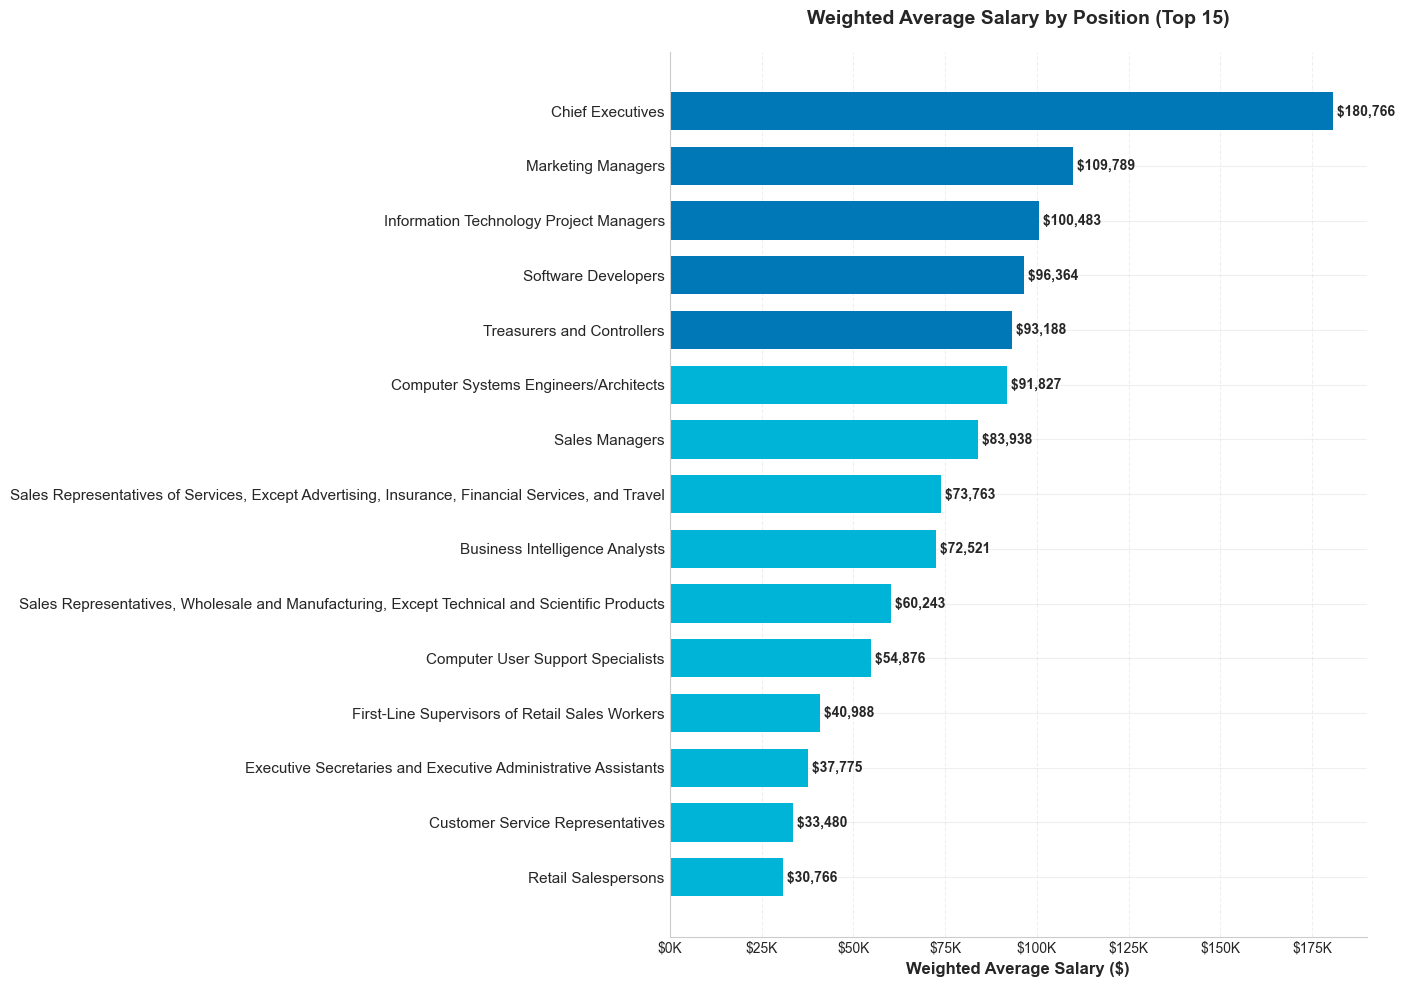

✓ Saved: output/company_overview/09_salary_by_position.png


In [59]:
# Salary by Position (if both columns exist) - Weighted
if salary_col and position_code_col in df.columns and position_title_col in df.columns:
    print("\n=" * 60)
    print("WEIGHTED AVERAGE SALARY BY TOP POSITIONS")
    print("=" * 60)
    
    # Filter to only rows with valid O*NET titles
    df_valid_positions = df[df[position_title_col].notna()].copy()
    
    # Get top 15 positions by weighted count (using onet_code)
    top_position_codes = weighted_value_counts(df_valid_positions, position_code_col, 'weight').head(15).index
    
    # Calculate weighted mean and median for each position
    def weighted_agg(group):
        valid = group[[salary_col, 'weight']].dropna()
        if len(valid) == 0:
            return pd.Series({'weighted_mean': np.nan, 'weighted_count': 0})
        w_mean = np.average(valid[salary_col], weights=valid['weight'])
        w_count = valid['weight'].sum()
        return pd.Series({'weighted_mean': w_mean, 'weighted_count': w_count})
    
    salary_by_position = df_valid_positions[df_valid_positions[position_code_col].isin(top_position_codes)].groupby(position_code_col).apply(weighted_agg).sort_values('weighted_mean', ascending=False)
    
    salary_by_position['weighted_mean'] = salary_by_position['weighted_mean'].round(2)
    salary_by_position['weighted_count'] = salary_by_position['weighted_count'].round(0).astype(int)
    
    # Add position titles to the display
    position_mapping = df_valid_positions.groupby(position_code_col)[position_title_col].first()
    salary_by_position['Position'] = [position_mapping[code] for code in salary_by_position.index]
    salary_by_position = salary_by_position[['Position', 'weighted_mean', 'weighted_count']]
    salary_by_position.columns = ['Position', 'Weighted Mean Salary', 'Weighted Count']
    
    display(salary_by_position)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 10))
    
    position_codes = salary_by_position.head(15).index
    position_titles = [position_mapping[code] for code in position_codes]
    means = salary_by_position.head(15)['Weighted Mean Salary'].values
    
    colors = [MCKINSEY_BLUE if i < 5 else MCKINSEY_LIGHT_BLUE for i in range(len(position_codes))]
    bars = ax.barh(range(len(position_codes)), means, color=colors, height=0.7)
    
    for i, (bar, val) in enumerate(zip(bars, means)):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' ${val:,.0f}',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(position_codes)))
    ax.set_yticklabels(position_titles, fontsize=11)
    ax.set_xlabel('Weighted Average Salary ($)', fontsize=12, fontweight='bold')
    ax.set_title('Weighted Average Salary by Position (Top 15)', fontsize=14, fontweight='bold', pad=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/09_salary_by_position.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_dir}/09_salary_by_position.png")

---
## Summary

This report provides a comprehensive **weighted** analysis of the S&P 500 workforce including:
- **Demographic statistics** (gender excl. "." rows, ethnicity, education)
- **Position analysis** (most common roles — shares computed within mapped O*NET subset)
- **Geographic distribution** (US cities only, deduplicated by largest population)
- **Remote work patterns** (weighted histogram or weighted bar chart depending on dtype)
- **Compensation analysis** (weighted histogram, weighted salary bands, weighted percentile curve)

All statistics and visualizations use the `weight` column for proper sampling adjustment, except the salary box plot (which is explicitly labeled unweighted since matplotlib boxplot does not support weights). Each row in the dataset is an employee-position record; a single `user_id` may appear multiple times.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# COMPANY-LEVEL SUMMARY TABLE (all SP500 companies, sorted by size)
# ══════════════════════════════════════════════════════════════════════

def company_stats(grp):
    w = grp["weight"].fillna(1.0)
    n = w.sum()

    sex_mask = grp["sex_predicted"].notna() & (grp["sex_predicted"] != ".")
    w_sex = w[sex_mask]
    pct_f = 100 * w_sex[grp.loc[sex_mask, "sex_predicted"] == "F"].sum() / w_sex.sum() if w_sex.sum() > 0 else np.nan

    eth_mask = grp["ethnicity_predicted"].notna()
    w_eth = w[eth_mask]; eth = grp.loc[eth_mask, "ethnicity_predicted"]; w_eth_t = w_eth.sum()
    pct_white = 100 * w_eth[eth == "White"].sum() / w_eth_t if w_eth_t > 0 else np.nan
    pct_black = 100 * w_eth[eth == "Black"].sum() / w_eth_t if w_eth_t > 0 else np.nan
    pct_hisp  = 100 * w_eth[eth == "Hispanic"].sum() / w_eth_t if w_eth_t > 0 else np.nan
    pct_api   = 100 * w_eth[eth == "API"].sum() / w_eth_t if w_eth_t > 0 else np.nan

    edu_mask = grp["highest_degree"].notna()
    w_edu = w[edu_mask]; edu = grp.loc[edu_mask, "highest_degree"]
    pct_bach = 100 * w_edu[edu.isin(["Bachelor","Master","MBA","Doctor"])].sum() / w_edu.sum() if w_edu.sum() > 0 else np.nan

    sal_mask = grp["salary"].notna()
    avg_sal = np.average(grp.loc[sal_mask, "salary"], weights=w[sal_mask]) if w[sal_mask].sum() > 0 else np.nan
    median_sal = weighted_percentile(grp, "salary", 0.5) if sal_mask.any() else np.nan

    sen_mask = grp["seniority"].notna()
    avg_sen = np.average(grp.loc[sen_mask, "seniority"], weights=w[sen_mask]) if w[sen_mask].sum() > 0 else np.nan

    return pd.Series({
        "n_employees":    round(n, 0),
        "avg_salary":     avg_sal,
        "median_salary":  median_sal,
        "avg_seniority":  avg_sen,
        "pct_female":     pct_f,
        "pct_bach_plus":  pct_bach,
        "pct_white":      pct_white,
        "pct_black":      pct_black,
        "pct_hispanic":   pct_hisp,
        "pct_api":        pct_api,
    })

ticker_col  = "ticker"  if "ticker"  in df.columns else None
company_col = "company" if "company" in df.columns else None
group_cols  = [c for c in [ticker_col, company_col] if c is not None]

df_comp_summary = (
    df.groupby(group_cols)
    .apply(company_stats)
    .reset_index()
    .sort_values("n_employees", ascending=False)
    .reset_index(drop=True)
)
df_comp_summary.index += 1

# Round for readability
for c in ["avg_salary","median_salary"]:
    df_comp_summary[c] = df_comp_summary[c].round(0)
for c in ["avg_seniority"]:
    df_comp_summary[c] = df_comp_summary[c].round(2)
for c in ["pct_female","pct_bach_plus","pct_white","pct_black","pct_hispanic","pct_api"]:
    df_comp_summary[c] = df_comp_summary[c].round(1)

print("=" * 80)
print("  ALL S&P 500 COMPANIES — SORTED BY NUMBER OF EMPLOYEES")
print("=" * 80)
print(f"  Companies: {len(df_comp_summary)}\n")
display(df_comp_summary)